# ENTRENAMIENTO DE MODELOS
---

### Clasificación de galaxias según su morfología

#### Integrantes

- `Crespo Neri, Diego Ubaldo` (`ubaldo.crespo@iteso.mx`)
- `Garibay Zepeda, Julio Andrés` (`julio.garibay@iteso.mx`)
- `Vázquez Sandoval, Isaac Ernesto` (`isaac.vazquez@iteso.mx`)

---
---

### Bibliotecas

In [16]:
# Básicas
import os
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

In [17]:
# Swag
style = "/home/toutl/code/.machine.mplstyle"
if os.path.exists(style):
    plt.style.use(style)

---
---

### Data:

##### 1. Lectura de los datos

In [18]:
# Paths de las carpetas donde se encuentran los datos
data_folder = Path("../../data/classification/")
processed_folder = data_folder / "processed"

In [19]:
# Leemos la metadata (etiquetas e ids)
metadata_df = pd.read_csv(processed_folder / "sample_64x64_10570.csv").astype(str)
display(metadata_df.head())

,image_id,class
0,110581,0
1,53890,0
2,268229,0
3,69751,0
4,294591,0


In [20]:
# Cargamos las imágenes procesadas
processed_images = np.load(processed_folder / "sample_64x64_10570.npz")
files = processed_images.files
print(files[:10])
print(len(files))

['110581', '53890', '268229', '69751', '294591', '287069', '58579', '49874', '17922', '7030']
10570


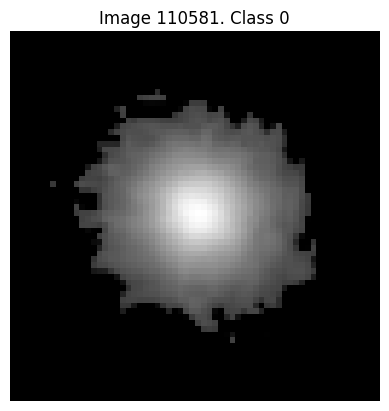

In [21]:
# Ejemplo de uso de una imágen
img_name = files[0]
idx = metadata_df.index[metadata_df["image_id"] == img_name][0]
img_class = metadata_df.at[idx, "class"]

plt.imshow(processed_images[img_name], cmap="gray")
plt.title(f"Image {img_name}. Class {img_class}")
plt.axis("off")
plt.show()

In [22]:
# Obtenemos un arreglo con todas las imágenes
images_array = np.empty((len(metadata_df), 64, 64))

for i, img_name in enumerate(processed_images):
    image = processed_images[img_name]

    # Asegurarse que las imágenes estén normalizadas
    if image.max() > 1 or image.min() < 0:
        raise Exception(f"ERROR.\nMax: {image.max()}. Min: {image.min()}")

    images_array[i] = image

In [23]:
# Revisando la cantidad de etiquetas respecto a la cantidad de imágenes, y congruencia de tamaños
print(images_array.shape, metadata_df["class"].shape)

(10570, 64, 64) (10570,)


---

##### 2. Separación de datos en entrenamiento y prueba

In [24]:
# Objeto que encapsule los datos
class Data:
    def __init__(self, X, y, random_state=35):
        # Train/test
        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=random_state, stratify=y
        )

        # Train/valid
        x_train, x_valid, y_train, y_valid = train_test_split(
            x_train, y_train, test_size=0.2, random_state=random_state, stratify=y_train
        )

        # Agregar canal
        self.x_train = x_train[..., None]
        self.y_train = np.asarray(y_train)

        self.x_valid = x_valid[..., None]
        self.y_valid = np.asarray(y_valid)

        self.x_test = x_test[..., None]
        self.y_test = np.asarray(y_test)

        # Crear versiones planas
        self.x_train_flat = self.x_train.reshape(len(self.x_train), -1)
        self.x_valid_flat = self.x_valid.reshape(len(self.x_valid), -1)
        self.x_test_flat = self.x_test.reshape(len(self.x_test), -1)

In [25]:
# Se genera el objeto para los datos
data = Data(
    X=images_array.astype("float32"),
    y=metadata_df["class"].astype("int8"),
)

In [26]:
# Checar
display(
    data.x_train.shape,
    data.x_train_flat.shape,
    data.y_train.shape,
    data.x_valid_flat.shape,
    data.x_valid.shape,
    data.y_valid.shape,
    data.x_test.shape,
    data.x_test_flat.shape,
    data.y_test.shape,
)

(6764, 64, 64, 1)

(6764, 4096)

(6764,)

(1692, 4096)

(1692, 64, 64, 1)

(1692,)

(2114, 64, 64, 1)

(2114, 4096)

(2114,)

---
---

### Modelos:

#### Introducción

El primer objetivo a probar será comparar 4 modelos sencillos para una clasificación de imágenes de galaxias como se ha estado trabajando.

La clasificaición será binaria siendo...
- `0`: S, galaxias con forma espiral.
- `1`: E, morfología elíptica.

Recordando que como outliers de la clasificación se consideran otros Artefactos u Objetos distintos a galaxias.

Los modelos a utilizar serán 4:

- **CNN** (Red Neuronal Convolucional): 
    - Es la favorita. El estado del arte para imágenes.
    - Representa un sistema visual, capaz de detectar bordes, texturas y formas.
    - Aprende patrones complejos a costa de una gran cantidad de imágenes.

- **MLP** (Perceptrón MultiCapa): 
    - Generaliza más que una CNN, tiene ceguera ante la espacialidad.
    - Util cuando no hay linealidad.
    - No es realmente utilizada para imágenes.

- **SVC** (Clasificador de Soporte Vectorial): 
    - No entiende espacialidad ni la estructura de las imágenes.
    - Bueno para decisiones de frontera.
    - No muy amigable con conjuntos de datos grandes.

- **LR** (Regresión Logística): 
    - Útil como base, para reconocer la necesidad de linealidad o estructuras complejas.
    - Bueno para establecer fronteras.

Las métricas consideradas para evaluar dichos modelos, deberán ser congruentes para el problema, una clasificación binaria.

Por lo tanto se utilizarán:

- Accuracy:
  - Indica la proporción de aciertos.
  - Podría cargar un ligero sesgo debido al que las clases tinene un balance de `60:40`, por esto mismo se complementa con otras métricas.

- Precision, Recall y F1-score:
  - Muestran el comportamiento del modelo con cada clase.
  - El F1 combina precisión y recall en un solo número.

- ROC–AUC:
  - Mide la capacidad del modelo para separar las dos clases.

La estructura del programa es la siguiente:
1. Se cargan los datos y separan en conjuntos de entrenamiento, validación y prueba.
2. Se entrenará una instancia sencilla de cada modelo.
    - Luego se compararán en bruto.
3. Con técnicas de ajuste de hiperparámetros se buscarán mejores versiones de cada modelo.
    - Y una comparación se realizará con los que obtengan las mejores métricas de cada uno.
4. Finalmente, se entrenará el mejor modelo que se haya obtenido con los datos sobrantes del muestreo y con la totalidad de los obtenidos.

---

#### Básicos
---

##### 1. CNN

In [27]:
# Bibliotecas
from keras.callbacks import EarlyStopping
from keras.layers import (BatchNormalization, Conv2D, Dense, Dropout, Flatten,
                          Input, MaxPooling2D)
from keras.models import Sequential
from keras.optimizers import Adam

In [12]:
def visualize_training(hist):
    plt.plot(hist.history["accuracy"])
    plt.plot(hist.history["val_accuracy"])
    plt.title("accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epochs")
    plt.legend(["training", "validation"], loc="lower right")
    plt.show()

    # training vs validation loss
    plt.plot(hist.history["loss"])
    plt.plot(hist.history["val_loss"])
    plt.title("loss")
    plt.ylabel("loss")
    plt.xlabel("epochs")
    plt.legend(["training", "validation"], loc="upper right")
    plt.show()

In [13]:
def build_binary_cnn(data):
    model = Sequential()

    model.add(Input(shape=data.x_train.shape[1:]))

    model.add(Conv2D(filters=32, kernel_size=3, padding="same", activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=32, kernel_size=3, padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=64, kernel_size=3, padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=128, kernel_size=3, padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=2))

    model.add(Dropout(0.2))
    model.add(Flatten())

    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.3))

    model.add(Dense(1, activation="sigmoid"))

    optimizer = Adam(learning_rate=3e-4)
    model.compile(
        loss="binary_crossentropy",
        optimizer=optimizer,  # type: ignore
        metrics=["accuracy"],
    )

    return model

In [14]:
# Callbacks para el fit del modelo, funcionan para encontrar el mejor epoch
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

In [ ]:
cnn_model = build_binary_cnn(data)
cnn_model.summary()

In [ ]:
hist_cnn = cnn_model.fit(
    data.x_train,
    data.y_train,
    batch_size=32,
    epochs=20,
    validation_data=(data.x_valid, data.y_valid),
    callbacks=[early_stop],
)

In [ ]:
visualize_training(hist_cnn)

score_cnn = cnn_model.evaluate(data.x_test, data.y_test, verbose=0)
print(f"Accuracy CNN: {score_cnn[1] * 100:.2f}%")

---

##### 2. MLP

In [ ]:
def build_binary_mlp(data):
    model = Sequential()

    model.add(Flatten(input_shape=data.x_train.shape[1:]))

    model.add(Dense(512, activation="relu"))
    model.add(Dropout(0.3))

    model.add(Dense(512, activation="relu"))
    model.add(Dropout(0.3))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(3e-4),  # type: ignore
        metrics=["accuracy"],
    )

    return model

In [ ]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

In [ ]:
mlp_model = build_binary_mlp(data)
mlp_model.summary()

In [ ]:
hist_mlp = mlp_model.fit(
    data.x_train,
    data.y_train,
    batch_size=32,
    epochs=40,
    validation_data=(data.x_valid, data.y_valid),
    callbacks=[early_stop],
)

In [ ]:
visualize_training(hist_mlp)

score_mlp = mlp_model.evaluate(data.x_test, data.y_test, verbose="0")
print(f"Accuracy CNN: {score_mlp[1] * 100:.2f}%")

---

##### 3. Support Vector Classifier

In [ ]:
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [ ]:
svc = SVC(kernel="rbf", C=5, gamma=0.001, class_weight="balanced")

svc.fit(data.x_train_flat, data.y_train)

y_pred = svc.predict(data.x_valid_flat)
print(classification_report(data.y_valid, y_pred))

In [ ]:
# utilizando PCA
pca = PCA(n_components=0.95, whiten=True, random_state=42)
x_train_pca = pca.fit_transform(data.x_train_flat)
x_valid_pca = pca.transform(data.x_valid_flat)

svc = SVC(kernel="rbf", C=5, gamma=0.001, class_weight="balanced")

svc.fit(x_train_pca, data.y_train)

y_pred = svc.predict(x_valid_pca)
print(classification_report(data.y_valid, y_pred))

---

##### 4. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
log_reg = LogisticRegression(max_iter=200, solver="liblinear")
log_reg.fit(data.x_train_flat, data.y_train)

In [ ]:
from sklearn.metrics import accuracy_score

preds = log_reg.predict(data.x_test_flat)
acc = accuracy_score(data.y_test, preds)
acc

#### Con ajuste de hiper-parámetros
---

##### 1. CNN

In [28]:
import keras_tuner as kt

In [ ]:
def build_model(hp):
    model = Sequential()

    f1 = hp.Choice("filters1", [16, 32, 64])
    f2 = hp.Choice("filters2", [32, 64, 128])
    lr = hp.Choice("lr", [1e-4, 3e-4, 1e-3])
    drop = hp.Choice("dropout", [0.2, 0.3, 0.4])

    model.add(Conv2D(f1, 3, activation="relu", padding="same",
                     input_shape=data.x_train.shape[1:]))
    model.add(MaxPooling2D(2))

    model.add(Conv2D(f2, 3, activation="relu", padding="same"))
    model.add(MaxPooling2D(2))

    model.add(Flatten())
    model.add(Dropout(drop))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(lr),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model



In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=10,
    directory="tuning",
    project_name="cnn_binary",
)

tuner.search(data.x_train, data.y_train,
             validation_data=(data.x_valid, data.y_valid),
             epochs=10)

---

##### 2. MLP

In [ ]:
def build_binary_mlp(hp, data):

    model = Sequential()

    # Flatten
    model.add(Flatten(input_shape=data.x_train.shape[1:]))

    units_1 = hp.Int("units_1", min_value=128, max_value=1024, step=128)
    dropout_1 = hp.Float("dropout_1", min_value=0.0, max_value=0.5, step=0.1)

    model.add(Dense(units_1, activation="relu"))
    model.add(Dropout(dropout_1))

    units_2 = hp.Int("units_2", min_value=128, max_value=1024, step=128)
    dropout_2 = hp.Float("dropout_2", min_value=0.0, max_value=0.5, step=0.1)

    model.add(Dense(units_2, activation="relu"))
    model.add(Dropout(dropout_2))

    #salida binaria
    model.add(Dense(1, activation="sigmoid"))

    lr = hp.Choice("learning_rate", [1e-2, 1e-3, 3e-4, 1e-4])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    hypermodel=lambda hp: build_binary_mlp(hp, data),
    objective="val_accuracy",
    max_trials=15,
    executions_per_trial=1, 
    directory="mlp_tuning",
    project_name="mlp_binary"
)

tuner.search(
    data.x_train, data.y_train,
    validation_data=(data.x_valid, data.y_valid),
    epochs=40,
    batch_size=32
)

---

##### 3. Support Vector Classifier

In [ ]:
# Con CV
pipe = Pipeline(
    [
        ("pca", PCA(n_components=0.95, whiten=True, random_state=42)),
        ("svc", SVC(class_weight="balanced", kernel="rbf")),
    ]
)

param_grid = {
    # "svc__C": [4, 5, 6],
    "svc__C": [5],
    # "svc__gamma": [0.0011, 0.0012, 0.00013],
    "svc__gamma": [0.0012],
}

grid = GridSearchCV(pipe, param_grid, scoring="roc_auc", verbose=True, n_jobs=-1)

grid.fit(data.x_train_flat, data.y_train)
print(grid.best_params_)

In [ ]:
y_pred = grid.predict(data.x_test_flat)
print(classification_report(data.y_test, y_pred))

---

##### 1. CNN

---
---

### Conclusiones